In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

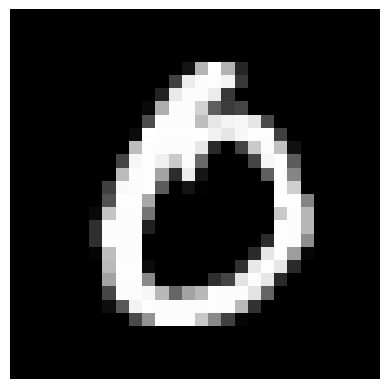

In [11]:
import matplotlib.pyplot as plt

# Extract the pixel values from the first row (excluding the label column)
pixels = train.iloc[200, 1:].values.reshape(28, 28)

# Display the image
plt.imshow(pixels, cmap='gray')
plt.axis('off')
plt.show()

In [20]:
import torch
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    train.iloc[:, 1:].values, train.iloc[:, 0].values, test_size=0.2, random_state=42
)

# Convert the pixel values to a PyTorch tensor
pixels_tensor = torch.tensor(np.asarray(X_train), dtype=torch.float32)
# Normalize the pixel values to the range [0, 1]
pixels_tensor = pixels_tensor / 255.0
# Extract the labels from the tensor
labels_tensor = pixels_tensor[:, 0].long()
# Extract the pixel values (excluding the label column)
pixels_tensor = pixels_tensor[:, 1:]
# Reshape the tensor to have shape (num_samples, 1, 28, 28)
pixels_tensor = pixels_tensor.view(-1, 1, 28, 28)
# Print the shape of the tensors
print("Shape of pixel tensor:", pixels_tensor.shape)
print("Shape of label tensor:", labels_tensor.shape)


RuntimeError: shape '[-1, 1, 28, 28]' is invalid for input of size 21047040

In [15]:
# Set up neural network
import torch.nn as nn
import torch.optim as optim
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x
# Initialize the model, loss function, and optimizer
model = SimpleCNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Training loop
num_epochs = 3
batch_size = 64
train_dataset = torch.utils.data.TensorDataset(pixels_tensor, labels_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")
# Save the trained model
torch.save(model.state_dict(), 'simple_cnn.pth')
# Load the trained model
#model = SimpleCNN()

Epoch [1/3], Loss: 0.0089
Epoch [2/3], Loss: 0.0000
Epoch [3/3], Loss: 0.0000


In [17]:
# Predict on test data
test_pixels = test.iloc[:, :].values.reshape(-1, 28, 28)
test_pixels_tensor = torch.tensor(test_pixels, dtype=torch.float32)
# Normalize the pixel values to the range [0, 1]
test_pixels_tensor = test_pixels_tensor / 255.0
# Reshape the tensor to have shape (num_samples, 1, 28, 28)
test_pixels_tensor = test_pixels_tensor.view(-1, 1, 28, 28)
# Set the model to evaluation mode
model.eval()
# Make predictions
with torch.no_grad():
    outputs = model(test_pixels_tensor)
    _, predicted = torch.max(outputs, 1)
# Convert predictions to a DataFrame
predictions_df = pd.DataFrame({'ImageId': range(1, len(predicted) + 1), 'Label': predicted.numpy()})
# Save predictions to a CSV file
predictions_df.to_csv('submission.csv', index=False)
# Display the first few predictions
print(predictions_df.head())

   ImageId  Label
0        1      0
1        2      0
2        3      0
3        4      0
4        5      0
